In [21]:
# BERTürk ile Aspect-Based Duygu Analizi
# Branch: yontem_berturk  |  Sorumlu: Dilara Çatalçam
!pip install transformers datasets scikit-learn seaborn -q

from transformers import set_seed
SEED = 42
set_seed(SEED)

In [22]:
import pandas as pd
import numpy as np

BASE_URL = "https://raw.githubusercontent.com/Xhymie/Konu-Bazli-Duygu-Analizi/yontem_cozmos/data/split/"

train_df = pd.read_csv(BASE_URL + "train.csv", encoding="utf-8-sig")
val_df   = pd.read_csv(BASE_URL + "val.csv",   encoding="utf-8-sig")
test_df  = pd.read_csv(BASE_URL + "test.csv",  encoding="utf-8-sig")

print(f"Train: {train_df.shape}, Val: {val_df.shape}, Test: {test_df.shape}")
print(train_df["sentiment"].value_counts())

Train: (2342, 3), Val: (506, 3), Test: (510, 3)
sentiment
pozitif    1336
negatif     822
notr        184
Name: count, dtype: int64


In [23]:
LABEL_MAP = {"negatif": 0, "notr": 1, "pozitif": 2}
INV_LABEL = {v: k for k, v in LABEL_MAP.items()}

for df in [train_df, val_df, test_df]:
    df["label"]      = df["sentiment"].map(LABEL_MAP)
    df["input_text"] = df["yorum"].astype(str) + " [SEP] " + df["aspect"].astype(str)

print("Örnek input:")
print(train_df["input_text"].iloc[0])
print("Label:", train_df["label"].iloc[0])

Örnek input:
ASUS ASUS ASUSU [SEP] genel
Label: 1


In [24]:
from sklearn.utils.class_weight import compute_class_weight
import torch

classes = np.array([0, 1, 2])
weights = compute_class_weight(
    class_weight="balanced",
    classes=classes,
    y=train_df["label"].values,
)
class_weights = torch.tensor(weights, dtype=torch.float)

print("Class weights:")
print(f"  negatif (0): {weights[0]:.3f}")
print(f"  notr    (1): {weights[1]:.3f}")
print(f"  pozitif (2): {weights[2]:.3f}")

Class weights:
  negatif (0): 0.950
  notr    (1): 4.243
  pozitif (2): 0.584


In [25]:
from transformers import AutoTokenizer
from torch.utils.data import Dataset

MODEL_NAME = "dbmdz/bert-base-turkish-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

class ABSADataset(Dataset):
    def __init__(self, df, tokenizer, max_len=128):
        self.texts     = df["input_text"].tolist()
        self.labels    = df["label"].tolist()
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        enc = self.tokenizer(
            self.texts[idx],
            max_length=self.max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )
        return {
            "input_ids":      enc["input_ids"].squeeze(),
            "attention_mask": enc["attention_mask"].squeeze(),
            "labels":         torch.tensor(self.labels[idx], dtype=torch.long)
        }

train_dataset = ABSADataset(train_df, tokenizer)
val_dataset   = ABSADataset(val_df,   tokenizer)
test_dataset  = ABSADataset(test_df,  tokenizer)

print("Dataset hazır!")
print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Dataset hazır!
Train: 2342, Val: 506, Test: 510


In [26]:
from transformers import AutoModelForSequenceClassification

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    ignore_mismatched_sizes=True
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device)

print("Model:", MODEL_NAME)
print("Cihaz:", device)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: dbmdz/bert-base-turkish-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those 

Model: dbmdz/bert-base-turkish-uncased
Cihaz: cuda


In [27]:
from transformers import TrainingArguments, Trainer, EarlyStoppingCallback
from sklearn.metrics import accuracy_score, f1_score
from torch.nn import CrossEntropyLoss

def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy":    accuracy_score(labels, preds),
        "macro_f1":    f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }

class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels  = inputs.get("labels")
        outputs = model(**inputs)
        logits  = outputs.get("logits")
        loss    = CrossEntropyLoss(weight=class_weights.to(logits.device))(logits, labels)
        return (loss, outputs) if return_outputs else loss

training_args = TrainingArguments(
    output_dir="./berturk_absa",
    seed=SEED,
    num_train_epochs=10,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=32,
    learning_rate=2e-5,
    weight_decay=0.01,
    warmup_ratio=0.1,
    eval_strategy="epoch",
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    logging_steps=50,
    fp16=True,
    report_to="none",
)

trainer = WeightedTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    compute_metrics=compute_metrics,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)

print("Fine-tuning başlıyor... (max 10 epoch, patience=2)")
trainer.train()

[transformers] warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Fine-tuning başlıyor... (max 10 epoch, patience=2)


Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.945320,0.742963,0.780632,0.662225,0.783923
2,0.698763,0.560757,0.841897,0.727364,0.843214
3,0.493397,0.725022,0.843874,0.725953,0.844730
4,0.421920,1.129104,0.837945,0.700390,0.829780


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=588, training_loss=0.6106829432403149, metrics={'train_runtime': 124.5137, 'train_samples_per_second': 188.092, 'train_steps_per_second': 11.806, 'total_flos': 616211624318976.0, 'train_loss': 0.6106829432403149, 'epoch': 4.0})

In [28]:
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score

preds_output = trainer.predict(test_dataset)
y_pred_idx   = np.argmax(preds_output.predictions, axis=-1)
y_true_idx   = test_df["label"].values

y_pred = [INV_LABEL[i] for i in y_pred_idx]
y_true = [INV_LABEL[i] for i in y_true_idx]

acc = accuracy_score(y_true, y_pred)
print(f"Test Accuracy: %{acc*100:.2f}")
print(classification_report(
    y_true, y_pred,
    labels=["pozitif", "negatif", "notr"],
    target_names=["pozitif", "negatif", "notr"]
))

Test Accuracy: %81.37
              precision    recall  f1-score   support

     pozitif       0.91      0.87      0.89       305
     negatif       0.78      0.83      0.80       160
        notr       0.36      0.40      0.38        45

    accuracy                           0.81       510
   macro avg       0.68      0.70      0.69       510
weighted avg       0.82      0.81      0.82       510



In [29]:
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import os

matplotlib.rcParams["font.family"] = "DejaVu Sans"
matplotlib.rcParams["axes.unicode_minus"] = False

VISUALS = "./visuals_berturk/"
os.makedirs(VISUALS, exist_ok=True)

ASPECTS = ["genel", "kargo", "kalite", "fiyat", "batarya", "ses_goruntu", "ambalaj"]
RENKLER = {"pozitif": "#2ecc71", "negatif": "#e74c3c", "notr": "#95a5a6"}

test_df["tahmin"] = y_pred
asp_order = [a for a in ASPECTS if a in test_df["aspect"].values]
print("Görselleştirme hazır. Kayıt klasörü:", VISUALS)

Görselleştirme hazır. Kayıt klasörü: ./visuals_berturk/


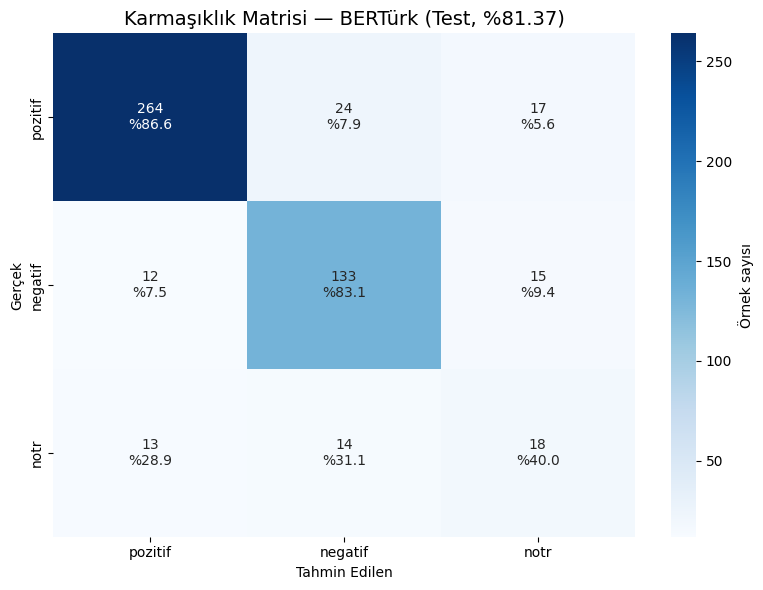

Kaydedildi: 01_karmasiklik_matrisi.png


In [30]:
labels_str = ["pozitif", "negatif", "notr"]
cm = confusion_matrix(y_true, y_pred, labels=labels_str)
cm_pct = cm / cm.sum(axis=1, keepdims=True) * 100

annot = np.empty_like(cm).astype(str)
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        annot[i, j] = f"{cm[i, j]}\n%{cm_pct[i, j]:.1f}"

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=annot, fmt="", cmap="Blues",
            xticklabels=labels_str, yticklabels=labels_str,
            cbar_kws={"label": "Örnek sayısı"})
plt.title(f"Karmaşıklık Matrisi — BERTürk (Test, %{acc*100:.2f})", fontsize=14)
plt.xlabel("Tahmin Edilen"); plt.ylabel("Gerçek")
plt.tight_layout()
plt.savefig(VISUALS + "01_karmasiklik_matrisi.png", dpi=150)
plt.show()
print("Kaydedildi: 01_karmasiklik_matrisi.png")

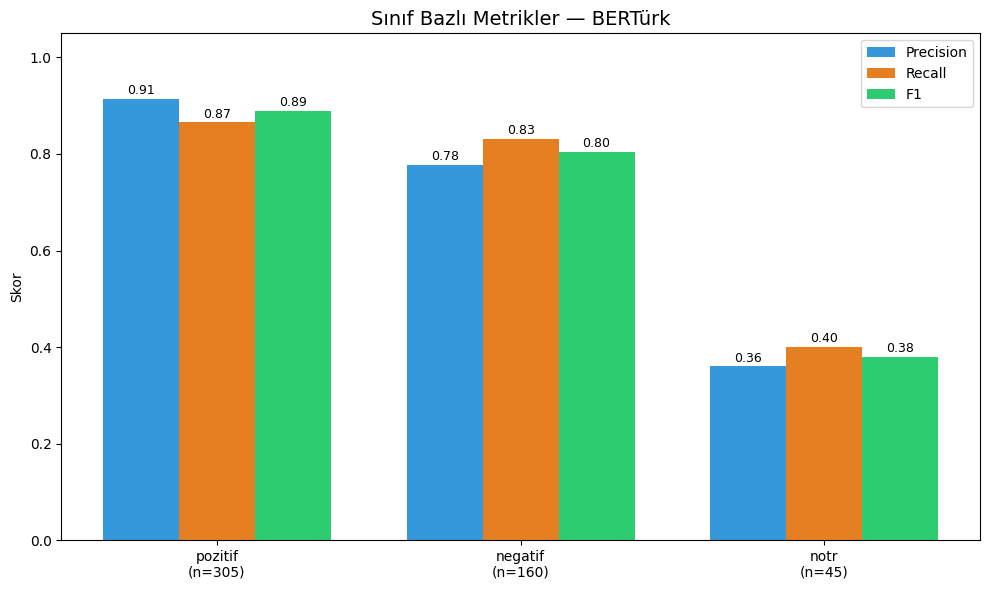

Kaydedildi: 02_sinif_bazli_metrikler.png


In [31]:
from sklearn.metrics import precision_recall_fscore_support

p, r, f1, sup = precision_recall_fscore_support(
    y_true, y_pred, labels=labels_str, zero_division=0
)

x = np.arange(len(labels_str))
w = 0.25
plt.figure(figsize=(10, 6))
plt.bar(x - w, p,  w, label="Precision", color="#3498db")
plt.bar(x,     r,  w, label="Recall",    color="#e67e22")
plt.bar(x + w, f1, w, label="F1",        color="#2ecc71")

for i in range(len(labels_str)):
    for off, val in zip([-w, 0, w], [p[i], r[i], f1[i]]):
        plt.text(x[i] + off, val + 0.01, f"{val:.2f}", ha="center", fontsize=9)

plt.xticks(x, [f"{l}\n(n={s})" for l, s in zip(labels_str, sup)])
plt.ylim(0, 1.05)
plt.ylabel("Skor")
plt.title("Sınıf Bazlı Metrikler — BERTürk", fontsize=14)
plt.legend()
plt.tight_layout()
plt.savefig(VISUALS + "02_sinif_bazli_metrikler.png", dpi=150)
plt.show()
print("Kaydedildi: 02_sinif_bazli_metrikler.png")

/tmp/ipykernel_4391/1567726231.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=test_df, x="aspect", order=asp_order, palette="Set2")


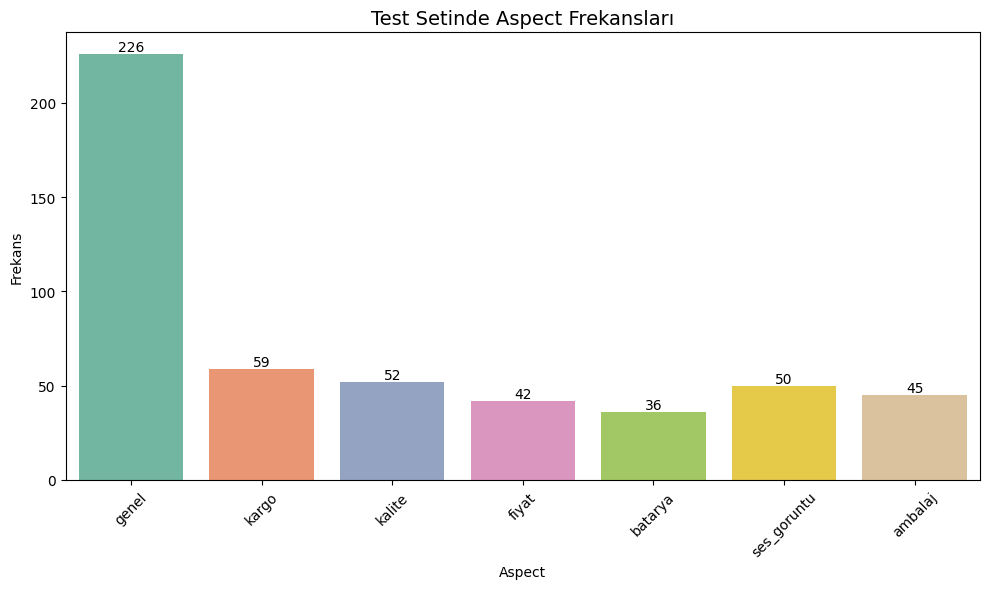

Kaydedildi: 03_aspect_frekanslari.png


In [32]:
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=test_df, x="aspect", order=asp_order, palette="Set2")
for c in ax.containers:
    ax.bar_label(c, fontsize=10)
plt.title("Test Setinde Aspect Frekansları", fontsize=14)
plt.xlabel("Aspect"); plt.ylabel("Frekans")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(VISUALS + "03_aspect_frekanslari.png", dpi=150)
plt.show()
print("Kaydedildi: 03_aspect_frekanslari.png")

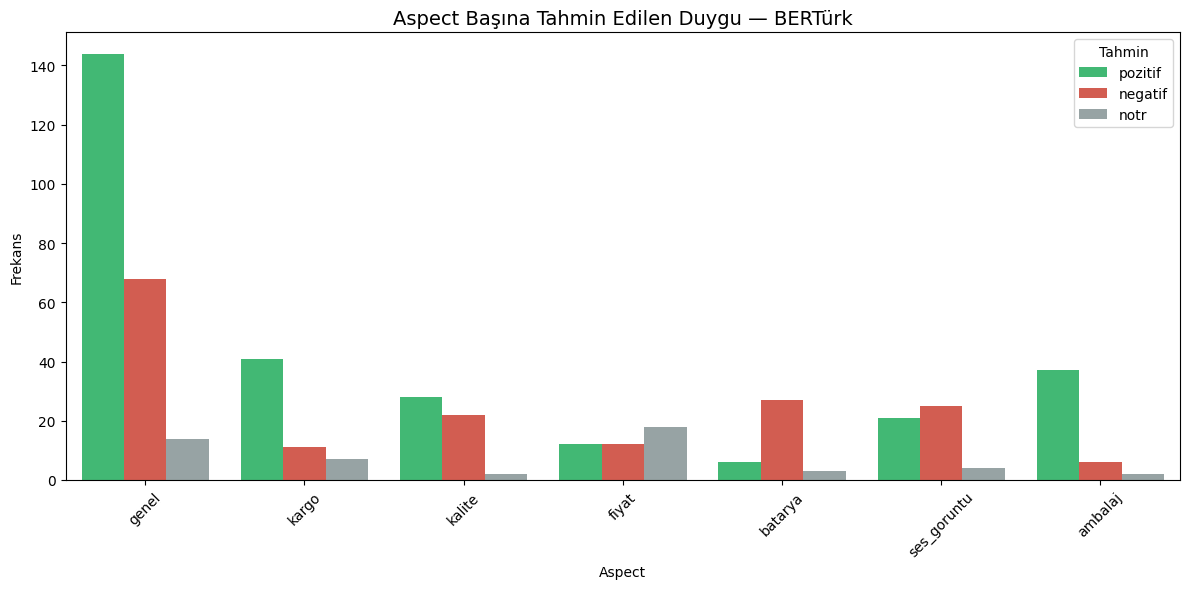

Kaydedildi: 04_aspect_sentiment_tahmin.png


In [33]:
plt.figure(figsize=(12, 6))
sns.countplot(data=test_df, x="aspect", hue="tahmin",
              order=asp_order, hue_order=["pozitif", "negatif", "notr"],
              palette=RENKLER)
plt.title("Aspect Başına Tahmin Edilen Duygu — BERTürk", fontsize=14)
plt.xlabel("Aspect"); plt.ylabel("Frekans")
plt.xticks(rotation=45)
plt.legend(title="Tahmin")
plt.tight_layout()
plt.savefig(VISUALS + "04_aspect_sentiment_tahmin.png", dpi=150)
plt.show()
print("Kaydedildi: 04_aspect_sentiment_tahmin.png")

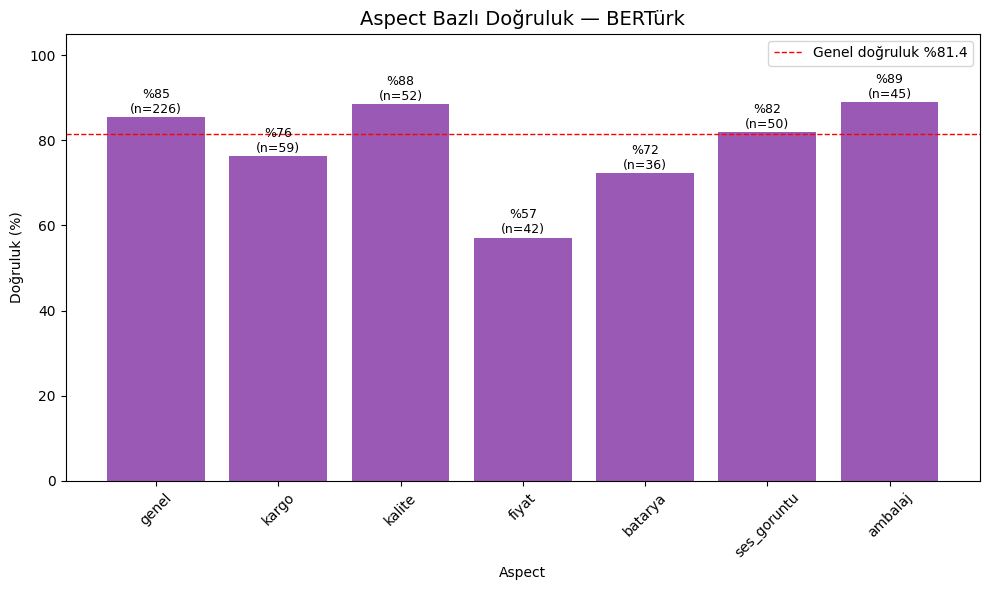

Kaydedildi: 05_aspect_dogruluk.png


In [34]:
test_df["dogru"] = (test_df["sentiment"] == test_df["tahmin"])
acc_by_aspect = test_df.groupby("aspect")["dogru"].mean().reindex(asp_order) * 100
n_by_aspect   = test_df.groupby("aspect").size().reindex(asp_order)

plt.figure(figsize=(10, 6))
bars = plt.bar(acc_by_aspect.index, acc_by_aspect.values, color="#9b59b6")
for b, n in zip(bars, n_by_aspect.values):
    plt.text(b.get_x() + b.get_width()/2, b.get_height() + 1,
             f"%{b.get_height():.0f}\n(n={n})", ha="center", fontsize=9)
plt.axhline(acc*100, color="red", ls="--", lw=1, label=f"Genel doğruluk %{acc*100:.1f}")
plt.ylim(0, 105)
plt.title("Aspect Bazlı Doğruluk — BERTürk", fontsize=14)
plt.xlabel("Aspect"); plt.ylabel("Doğruluk (%)")
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.savefig(VISUALS + "05_aspect_dogruluk.png", dpi=150)
plt.show()
print("Kaydedildi: 05_aspect_dogruluk.png")

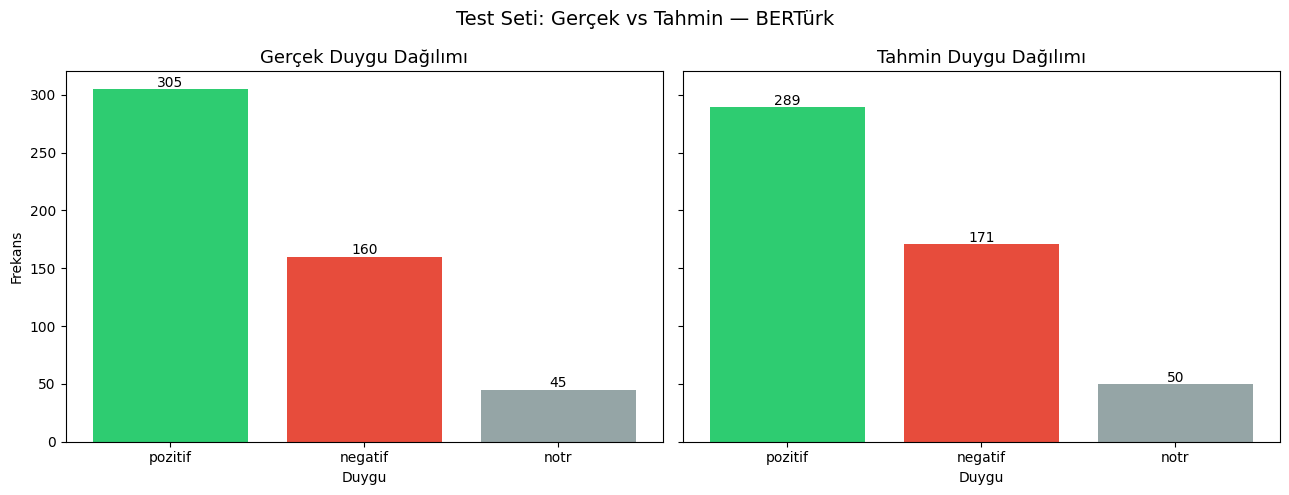

Kaydedildi: 06_gercek_vs_tahmin.png


In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
order_s = ["pozitif", "negatif", "notr"]

for ax, col, baslik in zip(axes, ["sentiment", "tahmin"], ["Gerçek", "Tahmin"]):
    vc = test_df[col].value_counts().reindex(order_s)
    ax.bar(vc.index, vc.values, color=[RENKLER[s] for s in order_s])
    for i, v in enumerate(vc.values):
        ax.text(i, v + 2, str(v), ha="center", fontsize=10)
    ax.set_title(f"{baslik} Duygu Dağılımı", fontsize=13)
    ax.set_xlabel("Duygu")
axes[0].set_ylabel("Frekans")
plt.suptitle("Test Seti: Gerçek vs Tahmin — BERTürk", fontsize=14)
plt.tight_layout()
plt.savefig(VISUALS + "06_gercek_vs_tahmin.png", dpi=150)
plt.show()
print("Kaydedildi: 06_gercek_vs_tahmin.png")

In [36]:
ytr = set(train_df["yorum"].astype(str).str.strip())
test_unique = test_df["yorum"].astype(str).str.strip().nunique()
ortak = set(test_df["yorum"].astype(str).str.strip()) & ytr

print(f"Train'de de görünen test yorumu: {len(ortak)} / {test_unique} "
      f"(%{100*len(ortak)/test_unique:.1f})")

if len(ortak) == 0:
    print("→ Sıfır örtüşme: yorum bazlı group split başarılı, veri sızıntısı YOK.")
else:
    mask = test_df["yorum"].astype(str).str.strip().isin(ytr)
    for ad, alt in [("Görülen yorum", test_df[mask]), ("Görülmeyen yorum", test_df[~mask])]:
        acc_alt = (alt["sentiment"] == alt["tahmin"]).mean() * 100
        print(f"  {ad:16s}: doğruluk %{acc_alt:.1f} (n={len(alt)})")

Train'de de görünen test yorumu: 0 / 333 (%0.0)
→ Sıfır örtüşme: yorum bazlı group split başarılı, veri sızıntısı YOK.


In [37]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, accuracy_score

majority = test_df["sentiment"].value_counts(normalize=True).max() * 100
print(f"Majority baseline    : accuracy %{majority:.1f}")

Xtr = (train_df["yorum"].astype(str) + " " + train_df["aspect"].astype(str)).tolist()
Xte = (test_df["yorum"].astype(str)  + " " + test_df["aspect"].astype(str)).tolist()
vec = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
clf = LogisticRegression(max_iter=1000, class_weight="balanced")
clf.fit(vec.fit_transform(Xtr), train_df["label"])
base_pred = clf.predict(vec.transform(Xte))

print(f"TF-IDF + LogReg      : accuracy %{100*accuracy_score(test_df['label'], base_pred):.1f}, "
      f"macro F1 {f1_score(test_df['label'], base_pred, average='macro'):.3f}")
print(f"BERTürk (bu çalışma) : accuracy %{acc*100:.1f}, "
      f"macro F1 {f1_score(y_true, y_pred, average='macro'):.3f}")

Majority baseline    : accuracy %59.8
TF-IDF + LogReg      : accuracy %78.0, macro F1 0.643
BERTürk (bu çalışma) : accuracy %81.4, macro F1 0.690


In [38]:
hatali = test_df[test_df["sentiment"] != test_df["tahmin"]]
print(f"Toplam hata: {len(hatali)} / {len(test_df)}")
print("\nNötr olması gerekirken kayan örnekler:")
for _, r in hatali[hatali["sentiment"] == "notr"].head(8).iterrows():
    print(f"  [{r['aspect']:11s}] gerçek=notr → tahmin={r['tahmin']:8s}: {str(r['yorum'])[:60]}")

Toplam hata: 95 / 510

Nötr olması gerekirken kayan örnekler:
  [genel      ] gerçek=notr → tahmin=negatif : Oyun oynamak ve iş yapmak istiyorsanız ikisini bir arada yap
  [kargo      ] gerçek=notr → tahmin=negatif : acilen dönüş yaparmisiniz kargomuz geldi ama pin şifre var o
  [genel      ] gerçek=notr → tahmin=negatif : Biraz yavaş ama idare eder
  [genel      ] gerçek=notr → tahmin=negatif : Fiyat performans ürünü kasıyor donuyor idare eder
  [genel      ] gerçek=notr → tahmin=pozitif : guzel ve kullanisli
  [ambalaj    ] gerçek=notr → tahmin=pozitif : iyiki almışım gerçekten çok iyi. paketleme normaldi ürün bay
  [batarya    ] gerçek=notr → tahmin=negatif : en alt seviye şarkı aralıksız 4 saat gidiyor şimdilik sadece
  [genel      ] gerçek=notr → tahmin=negatif : en alt seviye şarkı aralıksız 4 saat gidiyor şimdilik sadece


In [39]:
import shutil
from google.colab import files

test_df[["yorum", "aspect", "sentiment", "tahmin"]].to_csv(
    "./berturk_predictions.csv", index=False, encoding="utf-8-sig"
)
print("Tahminler kaydedildi: berturk_predictions.csv")

shutil.make_archive("./visuals_berturk", "zip", VISUALS)
files.download("./visuals_berturk.zip")
files.download("./berturk_predictions.csv")

Tahminler kaydedildi: berturk_predictions.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [40]:
!pip install captum -q
from transformers import AutoModelForSequenceClassification

TMP = "/content/berturk_eager"
model.save_pretrained(TMP)
tokenizer.save_pretrained(TMP)
viz_model = AutoModelForSequenceClassification.from_pretrained(
    TMP, attn_implementation="eager"
).to(device).eval()
print("viz_model (eager) hazır.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 14.1 MB/s eta 0:00:00


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

viz_model (eager) hazır.


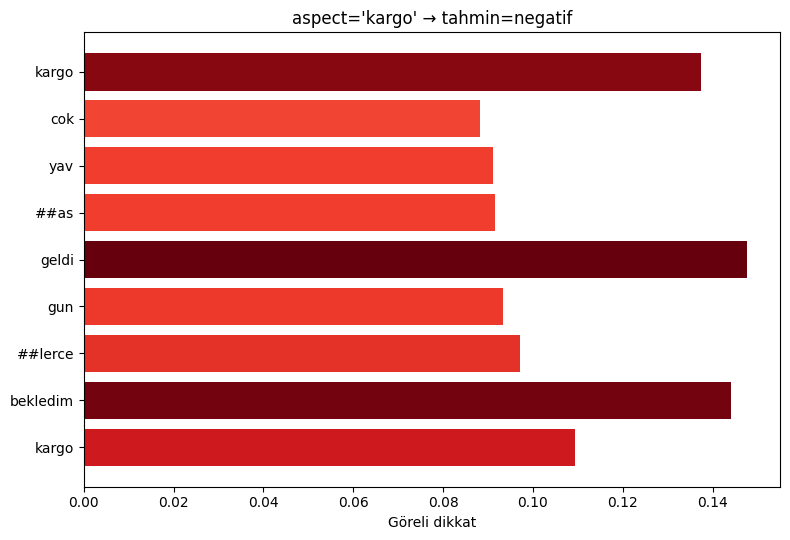

In [41]:
OZEL = {"[CLS]", "[SEP]", "[PAD]"}

def dikkat_gorseli(yorum, aspect, kayit=None):
    enc = tokenizer(f"{yorum} [SEP] {aspect}", return_tensors="pt",
                    truncation=True, max_length=128).to(device)
    with torch.no_grad():
        out = viz_model(**enc, output_attentions=True)
    att = out.attentions[-1][0].mean(0).cpu().numpy()   # son katman, head ortalaması
    tokens = tokenizer.convert_ids_to_tokens(enc["input_ids"][0])
    pred = INV_LABEL[out.logits.argmax(-1).item()]

    gelen = att.mean(axis=0)
    idx = [i for i, t in enumerate(tokens) if t not in OZEL]
    kelimeler = [tokens[i] for i in idx]
    skor = gelen[idx] / gelen[idx].sum()

    plt.figure(figsize=(8, 0.5 * len(kelimeler) + 1))
    plt.barh(range(len(kelimeler)), skor, color=plt.cm.Reds(skor / skor.max()))
    plt.yticks(range(len(kelimeler)), kelimeler)
    plt.gca().invert_yaxis()
    plt.xlabel("Göreli dikkat")
    plt.title(f"aspect='{aspect}' → tahmin={pred}")
    plt.tight_layout()
    if kayit:
        plt.savefig(kayit, dpi=150)
    plt.show()

dikkat_gorseli("kargo çok yavaş geldi günlerce bekledim", "kargo",
               kayit=VISUALS + "08_dikkat_ornek.png")

In [43]:
from captum.attr import LayerIntegratedGradients
from captum.attr import visualization as viz

ref_id = tokenizer.pad_token_id
cls_id, sep_id = tokenizer.cls_token_id, tokenizer.sep_token_id

def forward_func(input_ids, attention_mask):
    return viz_model(input_ids=input_ids, attention_mask=attention_mask).logits

lig = LayerIntegratedGradients(forward_func, viz_model.bert.embeddings)

def kayit_olustur(yorum, aspect):
    enc = tokenizer(f"{yorum} [SEP] {aspect}", return_tensors="pt",
                    truncation=True, max_length=128).to(device)
    ids, mask = enc["input_ids"], enc["attention_mask"]
    logits = forward_func(ids, mask)
    pred_id = logits.argmax(-1).item()
    pred = INV_LABEL[pred_id]
    prob = torch.softmax(logits, -1)[0, pred_id].item()

    ref = ids.clone()
    ozel = (ids == cls_id) | (ids == sep_id)
    ref[~ozel] = ref_id

    attr, delta = lig.attribute(
        inputs=ids, baselines=ref,
        additional_forward_args=(mask,),
        target=pred_id, n_steps=50, return_convergence_delta=True,
    )
    attr = attr.sum(dim=-1).squeeze(0)
    attr = (attr / torch.norm(attr)).cpu().detach().numpy()
    tokens = tokenizer.convert_ids_to_tokens(ids[0])

    return viz.VisualizationDataRecord(
        word_attributions=attr, pred_prob=prob, pred_class=pred,
        true_class="-", attr_class=pred, attr_score=attr.sum(),
        raw_input_ids=tokens, convergence_score=delta,
    )

ornekler = [
    ("ürün harika kaliteli çok memnunum", "kalite"),
    ("telefon çok güzel ama kargo çok yavaştı", "genel"),
    ("telefon çok güzel ama kargo çok yavaştı", "kargo"),
]
records = [kayit_olustur(y, a) for y, a in ornekler]

html_obj = viz.visualize_text(records)

# Otomatik kayıt: renkli tabloyu HTML olarak diske yaz
with open(VISUALS + "09_integrated_gradients.html", "w", encoding="utf-8") as f:
    f.write(html_obj.data)
print("Kaydedildi: 09_integrated_gradients.html")

html_obj   # notebook içinde de göster

True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
-,pozitif (0.96),pozitif,1.96,[CLS] uru ##n harika kaliteli cok memnunum [SEP] kalite [SEP]
-,negatif (0.58),negatif,0.94,[CLS] telefon cok guzel ama kargo cok yav ##ast ##ı [SEP] genel [SEP]
-,negatif (0.75),negatif,1.06,[CLS] telefon cok guzel ama kargo cok yav ##ast ##ı [SEP] kargo [SEP]


Kaydedildi: 09_integrated_gradients.html


True Label,Predicted Label,Attribution Label,Attribution Score,Word Importance
-,pozitif (0.96),pozitif,1.96,[CLS] uru ##n harika kaliteli cok memnunum [SEP] kalite [SEP]
-,negatif (0.58),negatif,0.94,[CLS] telefon cok guzel ama kargo cok yav ##ast ##ı [SEP] genel [SEP]
-,negatif (0.75),negatif,1.06,[CLS] telefon cok guzel ama kargo cok yav ##ast ##ı [SEP] kargo [SEP]


In [44]:
import shutil, os
from google.colab import files

CIKTI = "/content/berturk_ciktilar/"
os.makedirs(CIKTI, exist_ok=True)

# Tüm görseller + IG html (visuals_berturk klasöründen)
for f in os.listdir(VISUALS):
    shutil.copy(VISUALS + f, CIKTI + f)

# Tahminler CSV'si de pakete girsin
shutil.copy("./berturk_predictions.csv", CIKTI + "berturk_predictions.csv")

shutil.make_archive("/content/berturk_ciktilar", "zip", CIKTI)
files.download("/content/berturk_ciktilar.zip")
print("Her şey indiriliyor: berturk_ciktilar.zip")
print("İçerik:", sorted(os.listdir(CIKTI)))

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Her şey indiriliyor: berturk_ciktilar.zip
İçerik: ['01_karmasiklik_matrisi.png', '02_sinif_bazli_metrikler.png', '03_aspect_frekanslari.png', '04_aspect_sentiment_tahmin.png', '05_aspect_dogruluk.png', '06_gercek_vs_tahmin.png', '08_dikkat_ornek.png', '09_integrated_gradients.html', 'berturk_predictions.csv']
